<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


Estimated time needed: **30** minutes


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [1]:
!pip install pandas
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 125.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 143.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 183.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 180.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 175.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


Import pandas module


In [2]:
import pandas as pd


Import matplotlib


In [4]:
import matplotlib.pyplot as plt

## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [5]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

Load the data into a pandas dataframe:



Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:



In [ ]:
# df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")


## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [8]:
# Count duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

# Display duplicate rows
duplicates = df[df.duplicated()]

duplicates.head()

Number of duplicate rows: 20

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
65437,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65438,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
65439,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
65440,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
65441,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


The dataset contains 20 duplicate rows, indicating that some survey responses were repeated. If these duplicates are not removed, they could bias the analysis by inflating counts and affecting statistical results such as averages, distributions, and trends.

### Task 2: Analysis of Duplicate Response Patterns
1. Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.
   


In [9]:
# Find repeated patterns
pattern_duplicates = df.groupby(
    ['MainBranch', 'Employment', 'RemoteWork']
).size().reset_index(name='Count')

pattern_duplicates.sort_values(by='Count', ascending=False).head()

,MainBranch,Employment,RemoteWork,Count
0,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",15288
2,I am a developer by profession,"Employed, full-time",Remote,12196
1,I am a developer by profession,"Employed, full-time",In-person,7118
78,I am a developer by profession,"Independent contractor, freelancer, or self-em...",Remote,2815
8,I am a developer by profession,"Employed, full-time;Independent contractor, fr...",Remote,1754


This means:

15,288 respondents identified themselves as professional developers working full-time in a hybrid work environment.

Similarly:

12,196 respondents work fully remote
7,118 respondents work fully in-person

In [10]:
# Analyze other shared columns
df.groupby(
    ['MainBranch', 'Employment', 'RemoteWork']
)[['Country', 'EdLevel']].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)

Country  \
MainBranch                                         Employment                                         RemoteWork                                                       
I am a developer by profession                     Employed, full-time                                Hybrid (some remote, some in-person)  United States of America   
                                                                                                      In-person                             United States of America   
                                                                                                      Remote                                United States of America   
                                                   Employed, full-time;Employed, part-time            Hybrid (some remote, some in-person)  United States of America   
                                                                                                      In-person                                          Switzerland   
...                                                                                                                                                              ...   
I used to be a developer by profession, but no ... Student, full-time;Employed, part-time             Remote                                United States of America   
                                                   Student, full-time;Independent contractor, free... Hybrid (some remote, some in-person)                   Germany   
                                                                                                      Remote                                                 Germany   
                                                   Student, full-time;Not employed, but looking fo... Remote                                                   Egypt   
                                                   Student, part-time;Employed, part-time             Hybrid (some remote, some in-person)  United States of America   

                                                                                                                                                                                      EdLevel  
MainBranch                                         Employment                                         RemoteWork                                                                               
I am a developer by profession                     Employed, full-time                                Hybrid (some remote, some in-person)       Bachelor’s degree (B.A., B.S., B.Eng., etc.)  
                                                                                                      In-person                                  Bachelor’s degree (B.A., B.S., B.Eng., etc.)  
                                                                                                      Remote                                     Bachelor’s degree (B.A., B.S., B.Eng., etc.)  
                                                   Employed, full-time;Employed, part-time            Hybrid (some remote, some in-person)       Bachelor’s degree (B.A., B.S., B.Eng., etc.)  
                                                                                                      In-person                                  Bachelor’s degree (B.A., B.S., B.Eng., etc.)  
...                                                                                                                                                                                       ...  
I used to be a developer by profession, but no ... Student, full-time;Employed, part-time             Remote                                     Bachelor’s degree (B.A., B.S., B.Eng., etc.)  
                                                   Student, full-time;Independent contractor, free... Hybrid (some remote, some in-person)  Some college/university study without earning ...  
                                                    

The analysis examined most common Country and most common EdLevel within each response-pattern group.

Many groups commonly share:

Country → United States of America
Education → Bachelor’s degree

The analysis reveals that many respondents share similar professional and remote-work characteristics, especially among full-time developers working in hybrid or remote environments. These repeated response patterns do not indicate duplicate records, but rather reflect common workforce trends, particularly among respondents from the United States with bachelor’s degrees.

### Task 3: Visualize Shared Response Patterns
1. Create visualizations to show the distribution of shared response patterns across different categories.
2. Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.


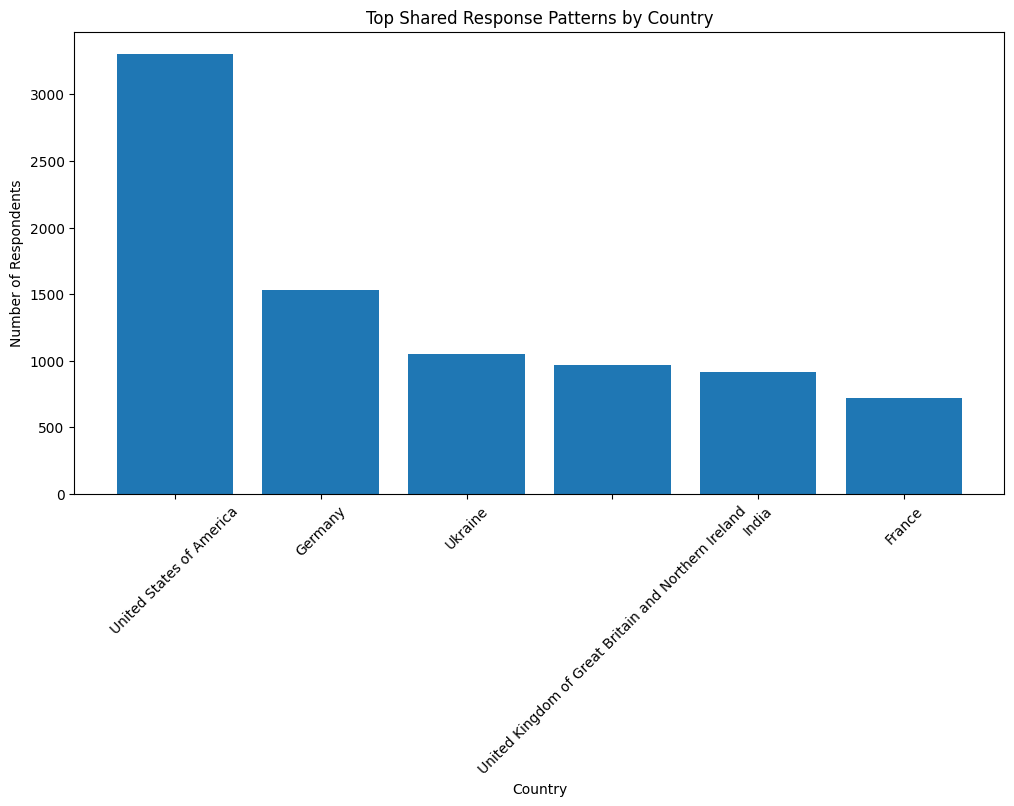

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Create grouped dataset (response patterns)
pattern_df = df.groupby(
    ['MainBranch', 'Employment', 'RemoteWork', 'Country']
).size().reset_index(name='Count')

# Bar Chart — Top Shared Response Patterns (by Country)
top_patterns = pattern_df.sort_values(by='Count', ascending=False).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_patterns['Country'],
    top_patterns['Count']
)

plt.title("Top Shared Response Patterns by Country")
plt.xlabel("Country")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45)

plt.show()

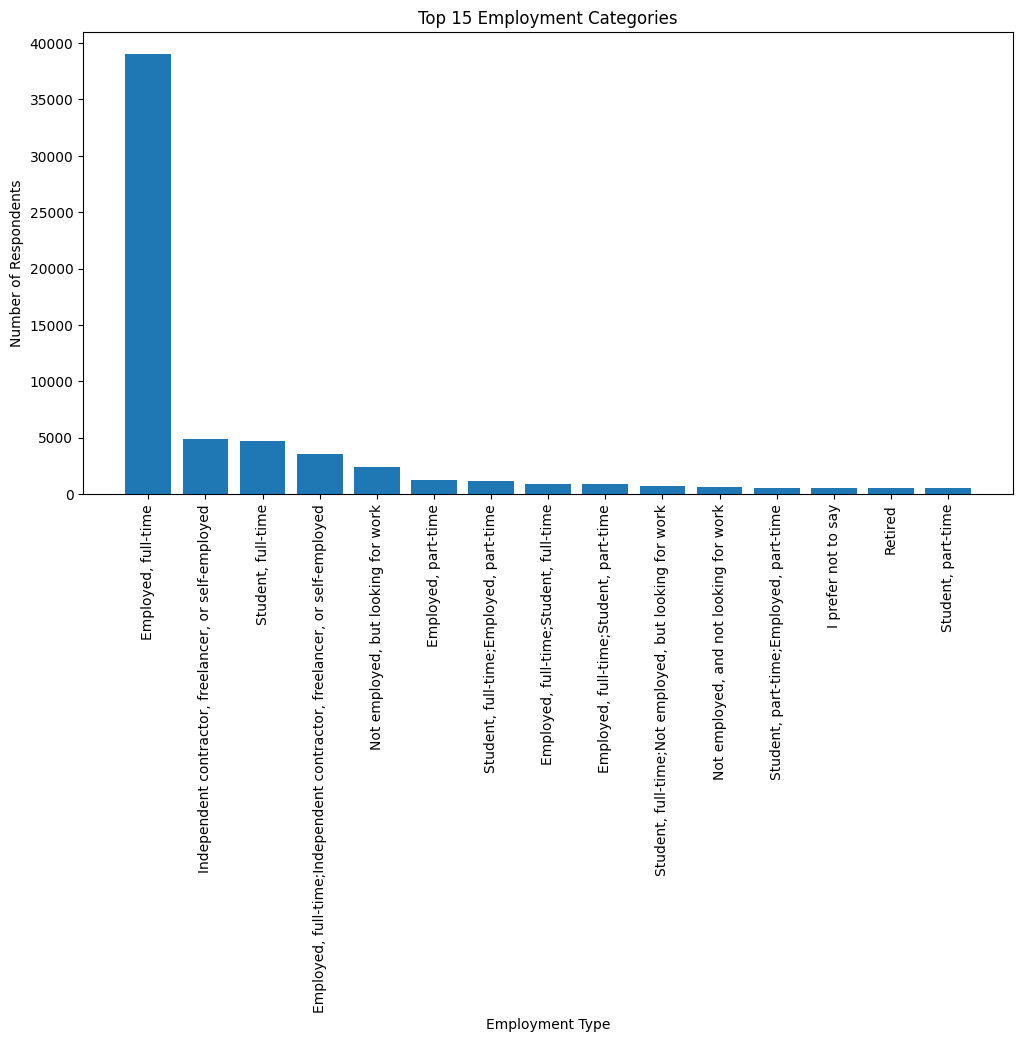

In [20]:
# Bar Chart — Employment Distribution (Top 15 only)
emp_top15 = df['Employment'].value_counts().head(15)

plt.figure(figsize=(12,6))

plt.bar(emp_top15.index, emp_top15.values)

plt.title("Top 15 Employment Categories")
plt.xlabel("Employment Type")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=90)

plt.show()

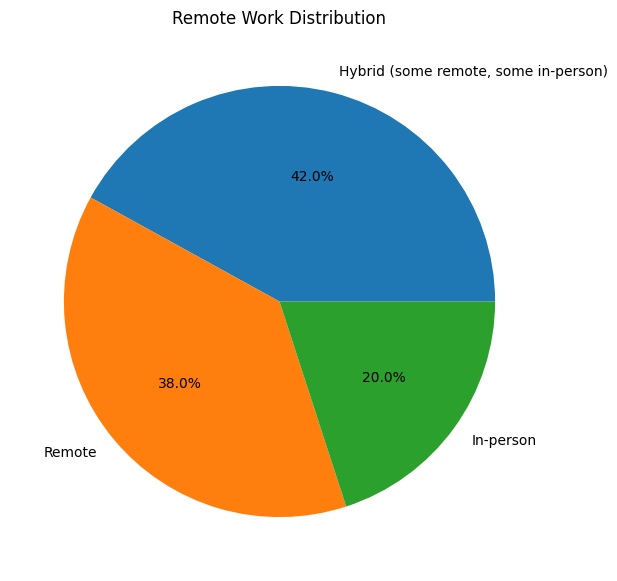

In [21]:
# Pie Chart — Remote Work Distribution

remote_counts = df['RemoteWork'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    remote_counts,
    labels=remote_counts.index,
    autopct='%1.1f%%'
)

plt.title("Remote Work Distribution")
plt.show()

### Task 4: Evaluate Duplicate Handling Strategy
1. Analyse the dataset to determine which column(s) define record uniqueness.
2. Assess whether removing rows based on a subset of columns (rather than complete row duplication) is appropriate.
Justify your decision with reference to the structure and purpose of the dataset.


The ResponseId column defines record uniqueness, while all other columns represent attributes of respondents rather than unique identifiers.

In [22]:
# Correct approach:Remove only exact duplicate rows
# Use full-row duplication check:
df_clean = df.drop_duplicates()

Removing duplicates should only be done on fully identical rows because the dataset represents independent survey responses. Using a subset of columns would incorrectly treat similar respondents as duplicates, distorting real-world workforce patterns and reducing data reliability.

## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


Step 1: Identify duplicate rows

Duplicate rows were detected using:

df.duplicated().sum()

This returned the total number of fully duplicated rows in the dataset.

To inspect them:

duplicates = df[df.duplicated()]
duplicates.head()

This helped confirm that some rows were exact copies of others across all columns.

Step 2: Remove duplicate rows

After verification, duplicates were removed using:

df_clean = df.drop_duplicates()

This ensures only fully identical rows were removed while preserving valid survey responses.

Step 3: Verification after removal

To confirm successful cleaning:

df_clean.duplicated().sum()

In [23]:
df_clean.duplicated().sum()

np.int64(0)

2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


Why full-row comparison was used:
Each row represents a unique survey respondent
ResponseId already acts as a unique identifier
Other columns (Employment, Country, Age, etc.) describe characteristics, not identity
Using only selected columns could incorrectly mark different people as duplicates

### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
